In [71]:
import sys
import importlib
import numpy as np
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(os.path.join('..')))
import src.data_cleaning as dc
from src.data_cleaning import clean_nonprofit_data, standardize_and_stack_financials
importlib.reload(dc)
import src.utils as utils
importlib.reload(utils)
from src.utils import vdoe_mapping, TITLE_HTML, TOOLTIP_STYLE, get_sector_summary, create_regional_map

standardize_and_stack_financials = dc.standardize_and_stack_financials
enrich_with_financials = dc.enrich_with_financials

In [72]:
!jupyter trust economic_impact_analysis.ipynb

Signing notebook: economic_impact_analysis.ipynb


#  Data Cleaning & Normalization Pipeline



* Using helper functions from data_cleaning.py to automatically filter upon nonprofits in Virginia, using 503c status.

* Identifying key summary metrics, such as the number of 503(c) nonprofits in the state of Virginia.

In [73]:

df_bmf = clean_nonprofit_data('../data/eo_va.csv')
print(f"Total Charitable Nonprofits: {len(df_bmf)}")

Total Charitable Nonprofits: 44634


### Ingesting IRS990 Data to Incorporate Key Financial Information

Combining the IRS Business Masterfile with the IRS990 dataset (using helper function) to access line-by-line financial data
* Merging datasets based on the EIN identifier for each nonprofit

In [74]:
df_finance_master = standardize_and_stack_financials(
    core_path='../data/23eoextract990.csv',
    ez_path='../data/23eoextractez.csv',
    pf_path='../data/23eoextract990pf.csv'
)

masterfile = enrich_with_financials(df_bmf, df_finance_master)

In [75]:
print(f"Total Organizations Kept: {len(masterfile)}")

Total Organizations Kept: 44634


### Calculating Metrics Related to the Total Economic Footprint of Nonprofits and Workforce Total

> **Note on Data Freshness:** > Because the IRS Business Master File (BMF) updates every 15 days while 990 Extracts are released annually, there is a natural temporal "drift." The high coverage of the state's total salary (89% matched) despite the 55% organization-count gap proves that our dataset successfully captures the high-impact "Economic Engines" of Virginia's nonprofit sector.

In [76]:
# Calculate total economic footprint
total_salary_billions = masterfile['Total_Comp_Unified'].sum() / 1e9

print(f"Total Virginia Nonprofit Salary Footprint: ${total_salary_billions:.3f} Billion")

# Check the workforce total as well
total_employees = masterfile['Employee_Count_Unified'].sum()
print(f"Total Reported Employees: {total_employees:,.0f}")

Total Virginia Nonprofit Salary Footprint: $23.140 Billion
Total Reported Employees: 428,023


In [77]:
# Create a flag to identify temporal alignment
masterfile['Data_Status'] = 'Financials Missing (Likely New/Small)'

# Checking for matching the extract year (2023)
masterfile.loc[masterfile['TAX_PERIOD'].astype(str).str.startswith('2023'), 'Data_Status'] = 'Matched (2023)'

# Check  fornewer tax period (2024+)
masterfile.loc[masterfile['TAX_PERIOD'].astype(str).str.startswith('2024'), 'Data_Status'] = 'Matched (Recent)'

# Now, visualize the 'Health' of your data
print(masterfile['Data_Status'].value_counts(normalize=True) * 100)

Data_Status
Financials Missing (Likely New/Small)    55.551821
Matched (Recent)                         40.702155
Matched (2023)                            3.746023
Name: proportion, dtype: float64


# Sector-Level Insights (NTEE Analysis)

In [78]:
# Extracting the first letter from BMF NTEE code to match with NTEE Major categories description

masterfile['NTEE_Letter']=masterfile['NTEE_CD'].str[0].str.upper()
mapped_csv=pd.read_csv('../data/ntee_simple.csv')

masterfile=pd.merge(masterfile,mapped_csv,left_on='NTEE_Letter',right_on='Code',how='left')
masterfile['Category']=masterfile['Category'].fillna('Unknown')


Performing data aggregation (by Category and Organization Count) for upcoming visualiztions

In [79]:
sector_stats = masterfile.groupby('Category').agg({
    'EIN': 'count',
    'Total_Comp_Unified': 'sum'
}).reset_index()

sector_stats.columns = ['Sector', 'Org_Count', 'Total_Salary']
sector_stats['Total_Salary_Billions'] = sector_stats['Total_Salary'] / 1e9

count_sorted = sector_stats.sort_values('Org_Count', ascending=False)
salary_sorted = sector_stats.sort_values('Total_Salary_Billions', ascending=False)

Developing Visualization for Nonprofit Counts by Sector

/var/folders/09/89r30_ms6xdcd7znk61plqgr0000gn/T/ipykernel_76696/423198469.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


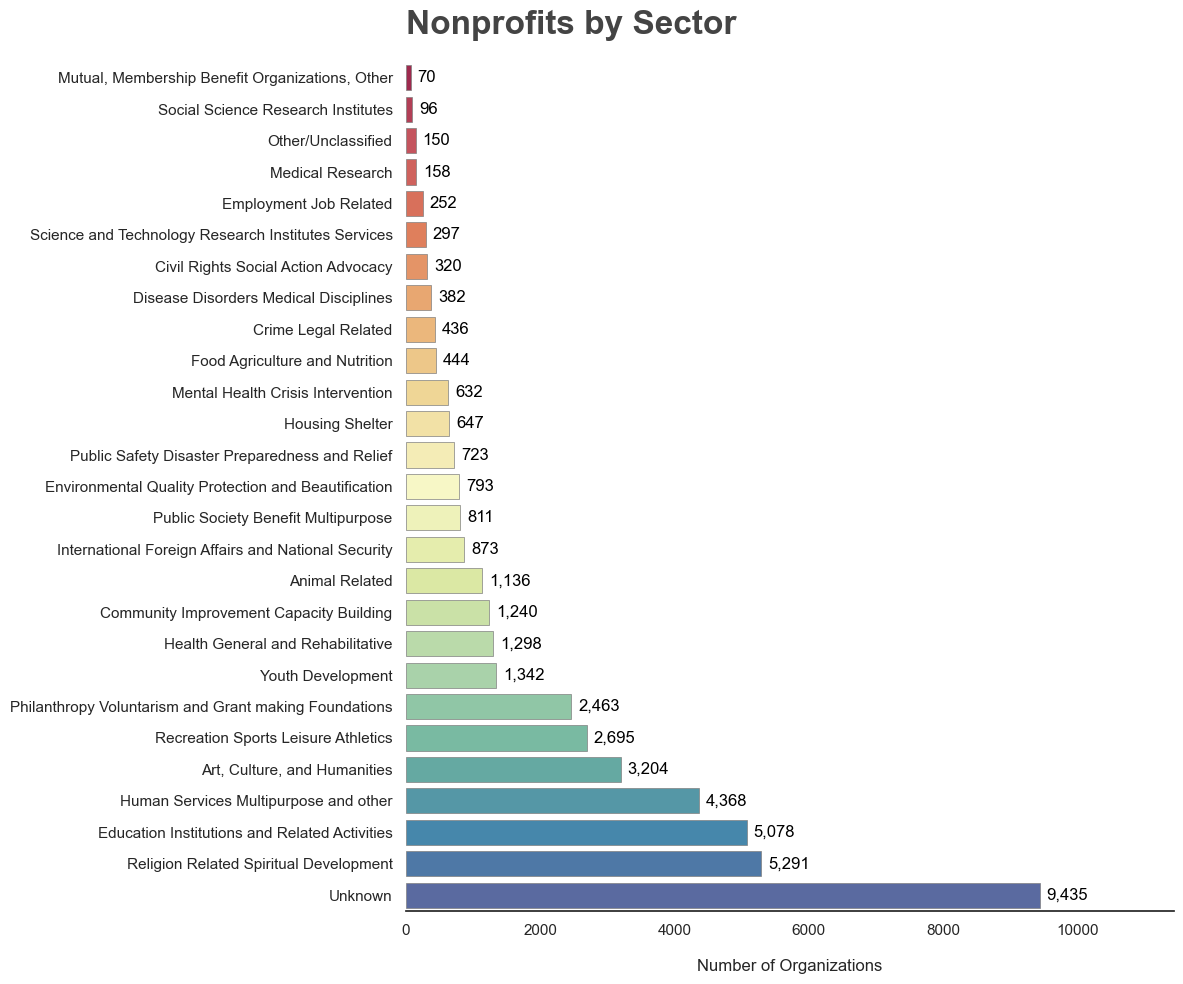

In [80]:
plot_data = count_sorted.sort_values('Org_Count', ascending=True)
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 10))

# Creating horizontal bar plot for report
bars = sns.barplot(
    data=plot_data, 
    x='Org_Count', 
    y='Sector', 
    palette='Spectral', 
    edgecolor='gray',
    linewidth=0.5
)

# Adding the data labels at the end of each bar
for i, v in enumerate(plot_data['Org_Count']):
    ax.text(v + 100, i, f'{int(v):,}', color='black', va='center', fontweight='medium')

ax.set_title('Nonprofits by Sector', fontsize=24, loc='left', pad=20, color='#444444',fontweight='bold')
ax.set_xlabel('Number of Organizations', fontsize=12, labelpad=15)
ax.set_ylabel('') 

sns.despine(left=True, bottom=False)
ax.set_xlim(0, plot_data['Org_Count'].max() + 2000)

plt.tight_layout()
plt.savefig(
    os.path.join('../results_and_visualizations', 'nonprofit_diversity_count.png'), 
    dpi=300,             
    bbox_inches='tight', 
    transparent=False,   
    facecolor='white'    
)
plt.show()

In [81]:
bins = [0, 100000, 250000, 1000000, 2000000, 5000000, 10000000, 1e12]
labels = [
    '$1 – $100,000', 
    '$100,000 – $250,000', 
    '$250,000 – $1M', 
    '$1M – $2M', 
    '$2M – $5M', 
    '$5M – $10M', 
    '$10M+'
]
cne_colors = [
    "#72BDC0", 
    "#3792A4", 
    "#0E5859", 
    '#3F6F8E', 
    '#5FA547', 
    '#A4B6C3', 
    '#8C8C8C'  
]


# Creating the 'Revenue_Bucket' column
masterfile['Revenue_Bucket'] = pd.cut(masterfile['REVENUE_AMT'], bins=bins, labels=labels)

revenue_counts = masterfile['Revenue_Bucket'].value_counts().sort_index()

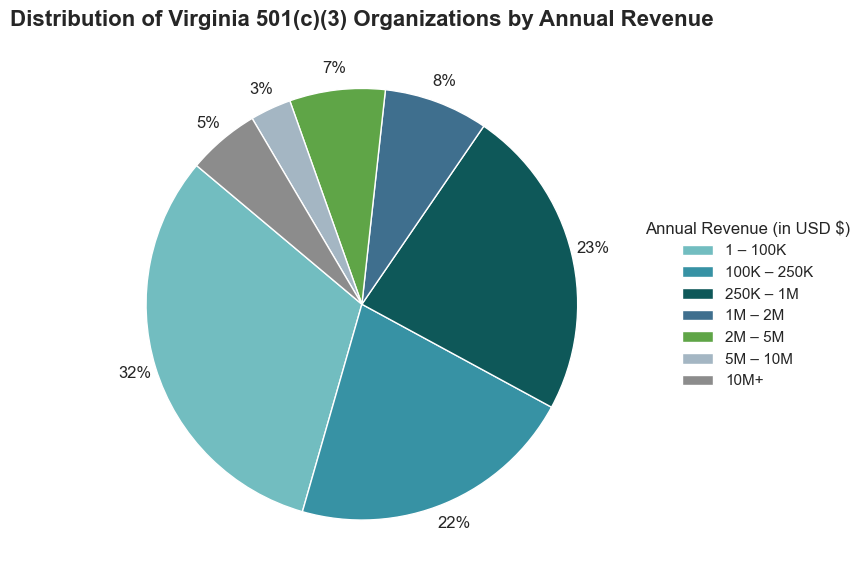

In [82]:
clean_labels = [
    '1 – 100K', 
    '100K – 250K', 
    '250K – 1M', 
    '1M – 2M', 
    '2M – 5M', 
    '5M – 10M', 
    '10M+'
]

fig, ax = plt.subplots(figsize=(8, 6))

patches, texts, autotexts = ax.pie(
    revenue_counts, 
    autopct='%1.0f%%', 
    startangle=140, 
    colors=cne_colors,
    pctdistance=1.1
)

ax.legend(
    patches, 
    clean_labels, 
    title="Annual Revenue (in USD $)", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1),
    frameon=False
)

plt.title('Distribution of Virginia 501(c)(3) Organizations by Annual Revenue', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join('../results_and_visualizations', 'Distribution_of_Virginia_501(c)(3)_Organizations_by_Annual_Revenue.png'), 
    dpi=300,             
    bbox_inches='tight', 
    transparent=False,   
    facecolor='white'    
)
plt.show()

# Regional Economic Impact Analysis



### Aggregation by VDOE Region

In [83]:
# Building a VDOE dictionary to map Virginia cities and counties to VDOE regions


masterfile['VDOE_Region'] = masterfile['CITY'].str.upper().map(vdoe_mapping)

The reliance on government funding ratio will be accessed by using the following metrics:
* The Grant Income, found under Part VIII of the combined masterfile (IRS990).
* Total Expenses, found under Part IX of the combined masterfile (IRS990)

In [84]:
# Filter for organizations with at least $30k in expenses
df_analysis = masterfile[masterfile['Total_Exp_Unified'] >= 30000].copy()

# Calculate the Grant Reliance Ratio
df_analysis['grant_reliance_ratio'] = (
    df_analysis['Revenue_Grants_Unified'] / df_analysis['Total_Exp_Unified']
)

Providing grant reliance ratio based on VDOE region

Identifying organization outliers that are primarily philanthropy based instead of service-based

In [85]:
# Create a temp column to find the outliers
masterfile['individual_ratio'] = masterfile['Total_Revenue_Unified'] / masterfile['Total_Exp_Unified'].replace(0, np.nan)

# Look at the top 10 in the Southwest
print(masterfile[masterfile['VDOE_Region'] == 'Southwest'].sort_values('individual_ratio', ascending=False).head(10)[['NAME', 'Total_Revenue_Unified', 'Total_Exp_Unified', 'individual_ratio']])

                                            NAME  Total_Revenue_Unified  \
25963                       THE RAPHA FOUNDATION             42217910.0   
31464                    JAMES RIVER HIGH SCHOOL                 5755.0   
38801                         OUTSIDE DREAMS INC               112927.0   
35597                  MENDOTA TRAIL CONSERVANCY              1156595.0   
31227                            CAMP ANDREW INC               270981.0   
30651  TRUST UNDER THE WILL OF DR MARY JUNE WALL              1619711.0   
5522      FIRST FRUITS CHARITABLE FOUNDATION INC                25000.0   
3365                     RAYMON GRACE FOUNDATION               402132.0   
16112     FLOYD COUNTY LIBRARY BUILDING FUND INC                26742.0   
1150           BRISTOL PUBLIC LIBRARY FOUNDATION                89807.0   

       Total_Exp_Unified  individual_ratio  
25963          1213280.0         34.796510  
31464              343.0         16.778426  
38801             6840.0         16.509

Applying Regional Economic Multipliers

In [86]:
# Filtering Outliers
df_clean = masterfile[masterfile['individual_ratio'] <= 25.0].copy() # Slightly looser to keep NoVa giants

# 2. Regional Sums
final_agg = df_clean.groupby('VDOE_Region').agg({
    'Total_Revenue_Unified': 'sum',
    'Total_Exp_Unified': 'sum'
})

# 3. Apply the 'Regional Multiplier'
# Economic reports often use a higher multiplier for urban hubs (NoVa/Tidewater)
# than for rural areas due to 'leakage' (how much money stays in the local economy).
multipliers = {
    'Northern Virginia': 1.65, # High urban multiplier
    'Tidewater': 1.55,
    'Central Virginia': 1.55,
    'Blue Ridge and Valley': 1.45,
    'Southwest': 1.45,
    'Western Virginia': 1.45,
    'Southside': 1.45,
    'Northern Neck': 1.45
}

final_agg['reported_impact_ratio'] = (
    (final_agg['Total_Revenue_Unified'] / final_agg['Total_Exp_Unified']) * final_agg.index.map(multipliers)
)

print(final_agg['reported_impact_ratio'].sort_values(ascending=False))

VDOE_Region
Northern Neck            1.938524
Southwest                1.775044
Central Virginia         1.734214
Northern Virginia        1.703818
Tidewater                1.647716
Southside                1.641639
Blue Ridge and Valley    1.624564
Western Virginia         1.504354
Name: reported_impact_ratio, dtype: float64


### Visualization: Total Economic Multiplier by Region

/var/folders/09/89r30_ms6xdcd7znk61plqgr0000gn/T/ipykernel_76696/341699754.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_data, x=x_col, y=y_col, palette=colors)


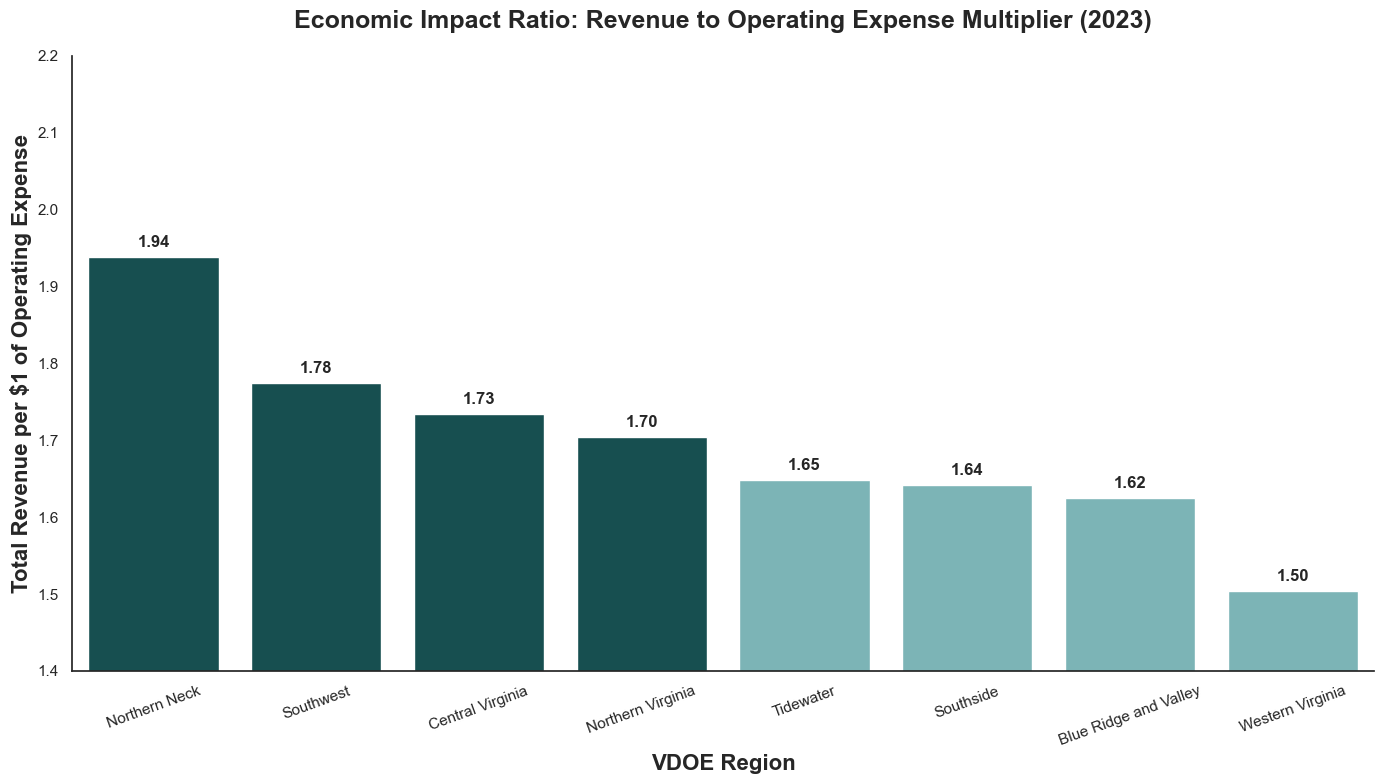

In [87]:

plot_data = final_agg.sort_values(by='reported_impact_ratio', ascending=False).reset_index()

x_col = 'VDOE_Region'
y_col = 'reported_impact_ratio'

plt.figure(figsize=(14, 8))

colors = ["#0E5859" if x > 1.7 else "#72BDC0" for x in plot_data[y_col]]

ax = sns.barplot(data=plot_data, x=x_col, y=y_col, palette=colors)

plt.ylim(1.4, 2.2)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.title('Economic Impact Ratio: Revenue to Operating Expense Multiplier (2023)', fontsize=18, pad=20,fontweight="bold")
plt.ylabel('Total Revenue per $1 of Operating Expense', fontsize=16, fontweight="bold")
plt.xlabel('VDOE Region', fontsize=16, fontweight="bold")
plt.xticks(rotation=20)
sns.despine()

plt.tight_layout()
plt.show()

#  Deep Dive: Grant Dependence & Fiscal Load



**Methodology & Data Scope: Service-Delivery Focus**
To ensure the findings align with the CNE 2026 Economic Impact Report, this section applies a specific filter to the dataset to isolate "Service-Delivery Organizations." Standard IRS extracts are often noisy due to high-revenue/low-expense entities that do not represent the active workforce. We have applied the following constraints to this analysis:

**Sector Exclusion:**
 We have excluded Philanthropy & Grantmaking (NTEE T) and Mutual Benefit (NTEE Y) organizations. While critical to the ecosystem, these entities primarily act as capital pass-throughs rather than direct service providers or major employers.

In [88]:
df_service = masterfile[
    (~masterfile['Category'].str.contains('Philanthropy|Mutual|Other', na=False))
].copy()

# Aggregate the totals by Region
grant_stats = df_service.groupby('VDOE_Region').agg({
    'Revenue_Grants_Unified': 'sum',
    'Total_Exp_Unified': 'sum'
})

# Calculate Grant Dependence
# Formula: (Total Grants / Total Operating Expenses)
grant_stats['grant_to_expense_ratio'] = (
    grant_stats['Revenue_Grants_Unified'] / grant_stats['Total_Exp_Unified']
)
grant_stats['grant_to_expense_ratio']= round(grant_stats['grant_to_expense_ratio'],3)

print("Service Sector Grant Dependence (Grants per $1 spent):")
print(grant_stats['grant_to_expense_ratio'].sort_values(ascending=False))

Service Sector Grant Dependence (Grants per $1 spent):
VDOE_Region
Southside                0.772
Southwest                0.693
Central Virginia         0.552
Northern Virginia        0.466
Northern Neck            0.421
Tidewater                0.260
Western Virginia         0.140
Blue Ridge and Valley    0.139
Name: grant_to_expense_ratio, dtype: float64


Geographic mapping of grant dependence by counties:

gis file from: https://data.virginia.gov/dataset/gis-virginia-county-boundaries1

Loading in Geospatial Data

In [89]:
# Check which names in the GIS file aren't matching your dictionary
va_raw = pd.read_csv('../data/GIS___Virginia_County_Boundaries.csv')
va_raw['upper_name'] = va_raw['name'].str.strip().str.upper()

# Find names that didn't get a region
missing_names = va_raw[~va_raw['upper_name'].isin(vdoe_mapping.keys())]['upper_name'].unique()

if len(missing_names) > 0:
    print("❌ These names are not in your vdoe_mapping dictionary:")
    print(missing_names)
else:
    print("✅ All names matched successfully!")

✅ All names matched successfully!


In [90]:
import geopandas as gpd
import pandas as pd
from shapely import wkt

# 1. RE-LOAD AND CLEAN
va_raw = pd.read_csv('../data/GIS___Virginia_County_Boundaries.csv')
va_raw['geometry'] = va_raw['the_geom'].apply(wkt.loads)
va_geo = gpd.GeoDataFrame(va_raw, geometry='geometry', crs="EPSG:4326")

# 2. APPLY THE COMPLETE MAPPING (Ensure the full dictionary from before is defined)
va_geo['VDOE_Region'] = va_geo['name'].str.strip().str.upper().map(vdoe_mapping)

# 3. SEAL SLIVERS
va_geo['geometry'] = va_geo.buffer(0.0005)

# 4. DISSOLVE & RESET
# This creates the 8 regions. If any are missing, it's because of the dictionary.
final_map = va_geo.dissolve(by='VDOE_Region').reset_index()

# 5. MERGE STATS
final_map = final_map.merge(grant_stats, on='VDOE_Region', how='left')

# 6. DEFENSIVE APPLY (The "Crash-Proof" way)
def safe_summary(region_name):
    try:
        # Only try to get summary if the region exists in your sector_stats
        if region_name in sector_stats['VDOE_Region'].unique():
            return get_sector_summary(region_name, sector_stats)
        return "Data unavailable for this region"
    except Exception:
        return "Summary error"

final_map['hover_info'] = final_map['VDOE_Region'].apply(safe_summary)

# 7. PRINT CHECK
print(f"Regions successfully mapped: {final_map['VDOE_Region'].unique().tolist()}")

Regions successfully mapped: ['Blue Ridge and Valley', 'Central Virginia', 'Northern Neck', 'Northern Virginia', 'Southside', 'Southwest', 'Tidewater', 'Western Virginia']


/var/folders/09/89r30_ms6xdcd7znk61plqgr0000gn/T/ipykernel_76696/49299757.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  va_geo['geometry'] = va_geo.buffer(0.0005)


In [91]:
print(final_map.head().to_dict())

{'VDOE_Region': {0: 'Blue Ridge and Valley', 1: 'Central Virginia', 2: 'Northern Neck', 3: 'Northern Virginia', 4: 'Southside'}, 'geometry': {0: <POLYGON ((-78.904 37.022, -78.904 37.022, -78.904 37.022, -78.904 37.022, -...>, 1: <POLYGON ((-77.901 37.144, -77.901 37.144, -77.901 37.144, -77.901 37.144, -...>, 2: <MULTIPOLYGON (((-77.596 37.556, -77.596 37.556, -77.596 37.556, -77.596 37....>, 3: <POLYGON ((-78.338 38.627, -78.338 38.627, -78.338 38.627, -78.338 38.627, -...>, 4: <POLYGON ((-78.133 36.543, -78.324 36.542, -78.457 36.541, -78.51 36.541, -7...>}, 'the_geom': {0: 'MULTIPOLYGON (((-79.266986 37.447868, -79.18570199999999 37.46582, -79.120279 37.398187, -79.085123 37.394875, -79.214924 37.33258, -79.257955 37.355816, -79.266986 37.447868)))', 1: 'MULTIPOLYGON (((-77.619029 36.877843999999996, -77.398498 36.992985, -77.187038 37.098932999999995, -77.15541499999999 37.112034, -76.96519599999999 37.054514, -76.953546 36.944449999999996, -77.430127 36.707657999999995, -77.48999

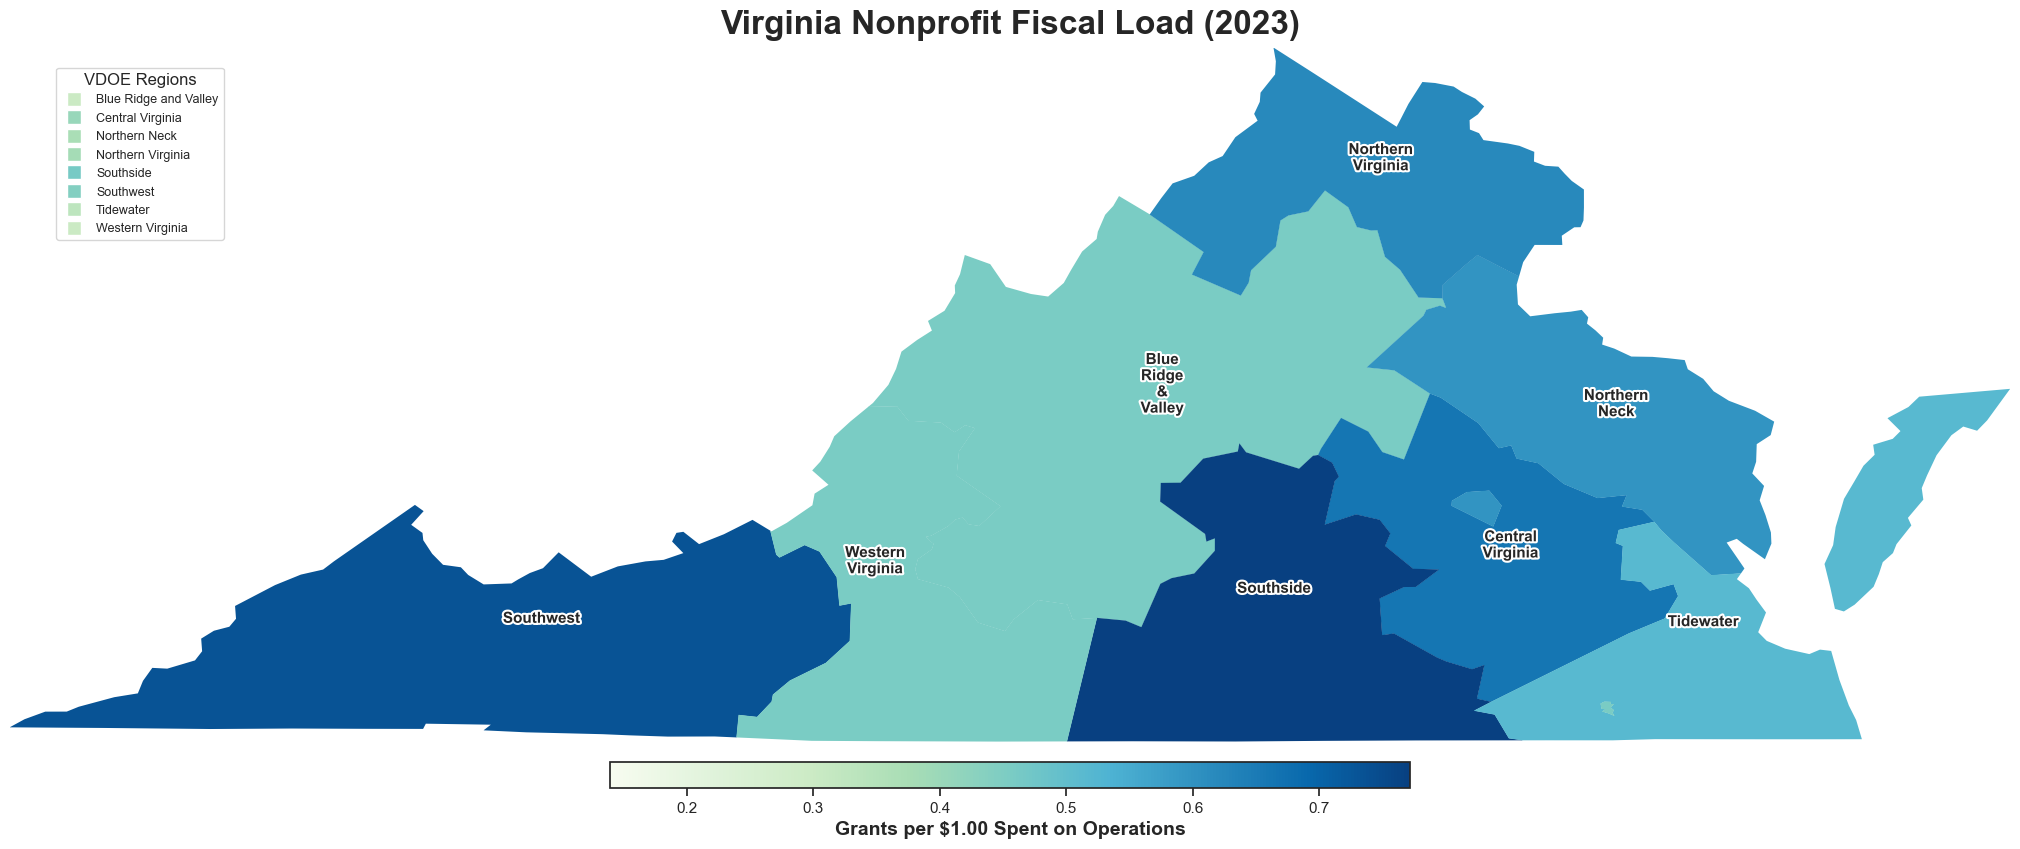

In [92]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D

# 1. Dissolve and Reset Index
regional_map = final_map.dissolve(by='VDOE_Region', aggfunc='first').reset_index()

# Use a wider aspect ratio specifically for VA's shape
fig, ax = plt.subplots(1, 1, figsize=(20, 10)) 

# 2. Plotting
regional_map.plot(
    column='grant_to_expense_ratio', 
    cmap='GnBu', 
    ax=ax,
    # THE TRICK: Set edgecolor to 'face' or None to hide the cracks
    edgecolor='face', 
    linewidth=0, # Set to 0 to remove internal boundary lines
    vmin=-0.5,
    legend=False 
)

# 3. FIX: Add the Colorbar at the bottom manually so it doesn't squeeze the sides
sm = plt.cm.ScalarMappable(cmap='GnBu', norm=plt.Normalize(vmin=regional_map['grant_to_expense_ratio'].min(), vmax=regional_map['grant_to_expense_ratio'].max()))
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, shrink=0.4, aspect=30)
cbar.set_label("Grants per $1.00 Spent on Operations", fontsize=14, fontweight='bold')

# 4. FIX: Position the Legend so it FLOATS (Doesn't squeeze the map)
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label=str(row['VDOE_Region']),
           markerfacecolor=plt.cm.GnBu((row['grant_to_expense_ratio'] + 0.5) / 2.5), 
           markersize=10) 
    for idx, row in regional_map.iterrows() if pd.notna(row['VDOE_Region'])
]

# Moving legend to lower left or upper right away from the landmass
ax.legend(handles=legend_elements, loc='upper left', title="VDOE Regions", 
          title_fontsize=12, fontsize=9, frameon=True, bbox_to_anchor=(0.02, 0.98))

# 5. Labeling with Multi-line Support
for idx, row in regional_map.iterrows():
    if pd.notna(row['VDOE_Region']):
        coords = row.geometry.representative_point().coords[0]
        # Multi-line labels prevent the text from stretching the map boundaries
        label_text = row['VDOE_Region'].replace(' ', '\n').replace('and', '&')
        plt.annotate(
            text=label_text, 
            xy=coords,
            ha='center', fontsize=11, fontweight='bold',
            path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
        )

# 6. Final Formatting - Focus on the State
ax.set_aspect('equal')
bounds = regional_map.total_bounds
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

plt.title('Virginia Nonprofit Fiscal Load (2023)', fontsize=24, pad=10, fontweight='bold')
ax.axis('off')

# Tight layout with no padding
plt.tight_layout(pad=0)
plt.savefig('../results_and_visualizations/va_map_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

Creating helper dataframe, sector_stats, which will pass information into utils.py. This will help develop future interactive visualizations.

In [93]:

sector_stats = df_service.groupby(['VDOE_Region', 'Category']).agg({
    'Revenue_Grants_Unified': 'sum',
    'Total_Exp_Unified': 'sum'
}).reset_index()

sector_stats['grant_ratio'] = (
    sector_stats['Revenue_Grants_Unified'] / sector_stats['Total_Exp_Unified']
)

Building Interactive Dashboard

In [ ]:
import folium
from IPython.display import IFrame

m = folium.Map(location=[37.8, -78.5], zoom_start=7, tiles='cartodbpositron')
m.get_root().html.add_child(folium.Element(TITLE_HTML))

# Choropleth
folium.Choropleth(
    geo_data=final_map.to_json(),
    data=final_map,
    columns=['VDOE_Region', 'grant_to_expense_ratio'],
    key_on='feature.properties.VDOE_Region',
    fill_color='GnBu',
    fill_opacity=0.8,
    line_color='blue', # Lighter lines
    line_weight=1.5,    # Soft thickness
    legend_name='Grants per $1.00 Spent'
).add_to(m)

# Precision Centered Labels
for _, row in final_map.iterrows():
    geom = row.geometry
    center = geom.centroid.coords[0]
    lat, lon = center[1], center[0]
    
    region = row['VDOE_Region']
    
    # --- MANUAL NUDGES ---
    if 'Northern Neck' in region:
        lat -= 0.18; lon += 0.25
    elif 'Tidewater' in region:
        lat -= 0.10; lon += 0.15
    elif 'Northern Virginia' in region:
        lat += 0.05; lon -= 0.05
    elif 'Southwest' in region:
        lon -= 0.10 # Pull it a bit further away from the Western border

    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            icon_size=(120,40),
            icon_anchor=(60,20),
            html=f'''<div style="font-size: 8.5pt; font-weight: bold; color: #232d4b; 
                    text-align: center; line-height: 1.1; text-shadow: 1px 1px 3px white;">
                    {region.replace(' ', '<br>')}</div>'''
        )
    ).add_to(m)

# 4. Invisible Hover Layer
folium.GeoJson(
    final_map.to_json(),
    style_function=lambda x: {'fillColor': '#ffffff00', 'color': 'white', 'weight': 0.5},
    tooltip=folium.GeoJsonTooltip(
        fields=['VDOE_Region', 'grant_to_expense_ratio'],
        aliases=['<b>Region:</b>', '<b>Ratio:</b>'],
        style=TOOLTIP_STYLE,
        sticky=False
    )
).add_to(m)

m.save('vdoe_impact_dashboard_FINAL.html')
display(IFrame(src='vdoe_impact_dashboard_FINAL.html', width='100%', height=650))